In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')
sns.set_palette("husl")
print("Setup complete!")

Setup complete!


# Kenya (Nairobi) - Climate Data Analysis

**Station:** Nairobi | **Elevation:** ~1,795m | **Period:** 2015-2026

Nairobi sits at a lower elevation than Addis Ababa but still qualifies as a 
highland climate. Kenya's climate is characterized by bimodal rainfall and 
moderate temperatures influenced by its equatorial location and altitude.

In [2]:
df = pd.read_csv('../data/kenya.csv')
df['Country'] = 'Kenya'
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df.replace(-999, np.nan, inplace=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Shape: (4108, 16)
Date range: 2015-01-01 to 2026-03-31


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1,2015
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1,2015
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1,2015
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1,2015
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1,2015


In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
print("Missing values (>0%):")
print(missing_pct[missing_pct > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values (>0%):
Series([], dtype: float64)

Duplicate rows: 0


In [4]:
df_clean = df.copy()
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
df_clean[weather_cols] = df_clean[weather_cols].ffill()
df_clean.to_csv('../data/kenya_clean.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!


In [5]:
print("KENYA TEMPERATURE SUMMARY")
print(f"Mean T2M: {df_clean['T2M'].mean():.1f}°C")
print(f"Max T2M: {df_clean['T2M'].max():.1f}°C")
print(f"Min T2M: {df_clean['T2M'].min():.1f}°C")
print(f"Std Dev: {df_clean['T2M'].std():.1f}°C")

KENYA TEMPERATURE SUMMARY
Mean T2M: 20.4°C
Max T2M: 25.4°C
Min T2M: 15.3°C
Std Dev: 1.4°C


In [6]:
# Outlier Detection using Z-score
print("OUTLIER DETECTION (|Z| > 3):")
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
for col in outlier_cols:
    if col in df_clean.columns:
        z_scores = np.abs(stats.zscore(df_clean[col].dropna()))
        outliers = (z_scores > 3).sum()
        print(f"  {col}: {outliers} outliers ({(outliers/len(df_clean))*100:.1f}%)")

OUTLIER DETECTION (|Z| > 3):
  T2M: 8 outliers (0.2%)
  T2M_MAX: 3 outliers (0.1%)
  T2M_MIN: 9 outliers (0.2%)
  PRECTOTCORR: 92 outliers (2.2%)
  RH2M: 6 outliers (0.1%)
  WS2M: 0 outliers (0.0%)
  WS2M_MAX: 6 outliers (0.1%)


**Outlier Detection Results:**

The Z-score analysis (|Z| > 3) identified the following outliers:
- T2M: 8 outliers (0.2%) - Negligible, retained
- T2M_MAX: 3 outliers (0.1%) - Negligible, retained
- T2M_MIN: 9 outliers (0.2%) - Minor, retained as valid temperature variations
- PRECTOTCORR: 92 outliers (2.2%) - These represent extreme rainfall events
  (up to 51.65 mm/day), not data errors. Retained for flood analysis
- RH2M: 6 outliers (0.1%) - Negligible, retained
- WS2M: 0 outliers - No action needed
- WS2M_MAX: 6 outliers (0.1%) - Negligible, retained

**Decision:** All outliers were retained. The precipitation outliers capture
extreme weather events critical for climate vulnerability assessment. All other
outlier counts are minimal and do not affect summary statistics significantly.

**Temperature Observations:**

Kenya (Nairobi) has a mean temperature of 20.4 degrees Celsius, which is 
4.3 degrees warmer than Ethiopia (Addis Ababa at 16.1 degrees). This is 
expected given Nairobi's lower elevation (1,795m vs 2,355m).

Key findings:
- Temperature range: 15.3 to 25.4 degrees Celsius
- Low variability (std = 1.4) indicates stable year-round temperatures
- Warmer than Ethiopia but still moderate by tropical standards
- No extreme heat events (T2M_MAX stays below 35 degrees)

The 4.3 degree difference between these two East African capitals, separated 
by only 560m of elevation, demonstrates how critical altitude is for climate 
in this region. A warming of 2-3 degrees in Nairobi would bring temperatures 
close to levels that could affect labor productivity and increase cooling needs.

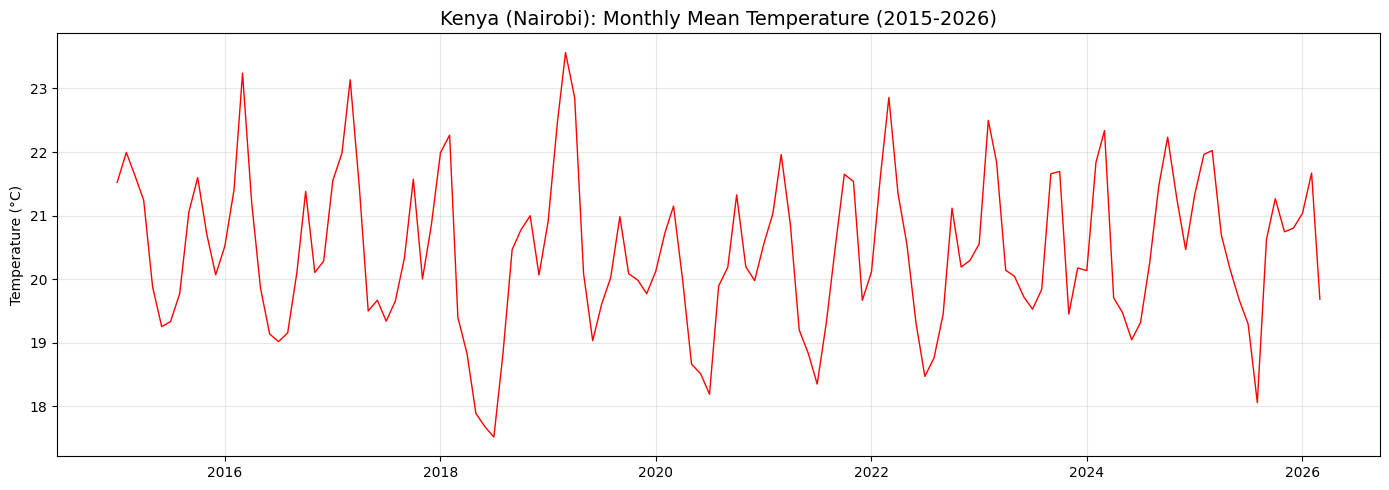

In [7]:
monthly_temp = df_clean.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp[['Year', 'Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], 'r-', linewidth=1)
plt.title('Kenya (Nairobi): Monthly Mean Temperature (2015-2026)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
print("KENYA PRECIPITATION SUMMARY")
print(f"Mean daily precip: {df_clean['PRECTOTCORR'].mean():.2f} mm")
print(f"Max daily precip: {df_clean['PRECTOTCORR'].max():.2f} mm")
print(f"Days with rain: {(df_clean['PRECTOTCORR'] > 0).sum()}")

KENYA PRECIPITATION SUMMARY
Mean daily precip: 1.47 mm
Max daily precip: 51.65 mm
Days with rain: 3848


**Precipitation Observations:**

Kenya receives rain on 94 percent of days (3,848 out of 4,108 days), but 
with relatively light intensity (mean 1.47 mm/day). The maximum recorded 
daily precipitation is 51.6 mm.

Comparison with Ethiopia:
- Kenya has MORE rainy days (3,848 vs 3,256) but LESS total precipitation
- Kenya's rain is lighter but more frequent
- Ethiopia's rain is heavier but less frequent (max 82.3 mm vs 51.6 mm)

This pattern means Kenya is less prone to flooding from individual storms 
but may experience more persistent wet conditions during rainy seasons.

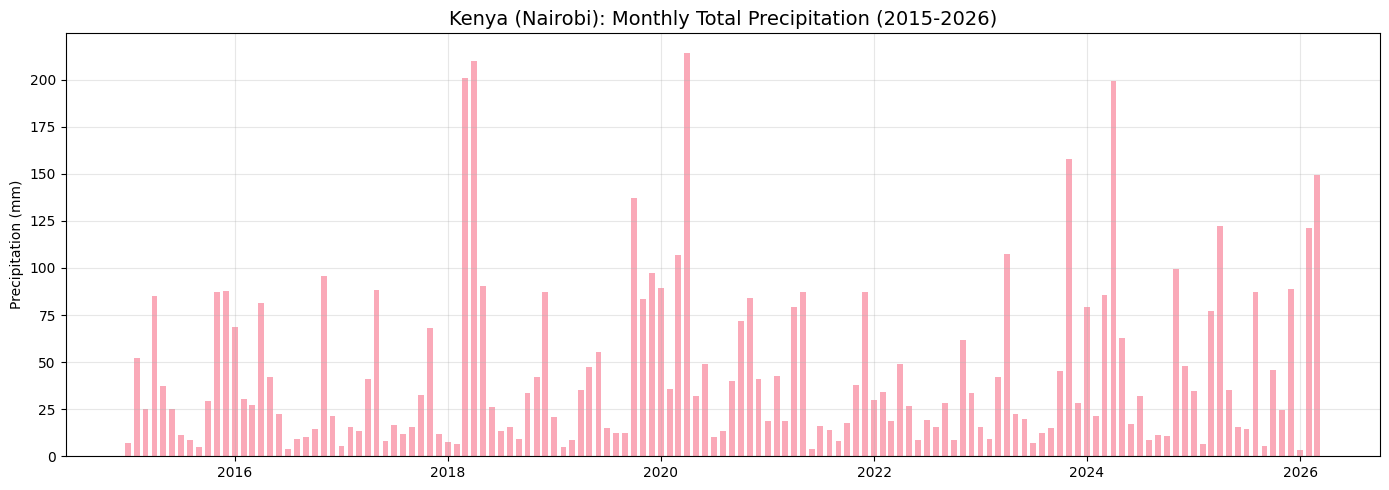

In [9]:
monthly_p = df_clean.groupby(['Year', 'Month'])['PRECTOTCORR'].sum().reset_index()
monthly_p['Date'] = pd.to_datetime(monthly_p[['Year', 'Month']].assign(Day=1))
plt.figure(figsize=(14, 5))
plt.bar(monthly_p['Date'], monthly_p['PRECTOTCORR'], width=20, alpha=0.6)
plt.title('Kenya (Nairobi): Monthly Total Precipitation (2015-2026)', fontsize=14)
plt.ylabel('Precipitation (mm)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

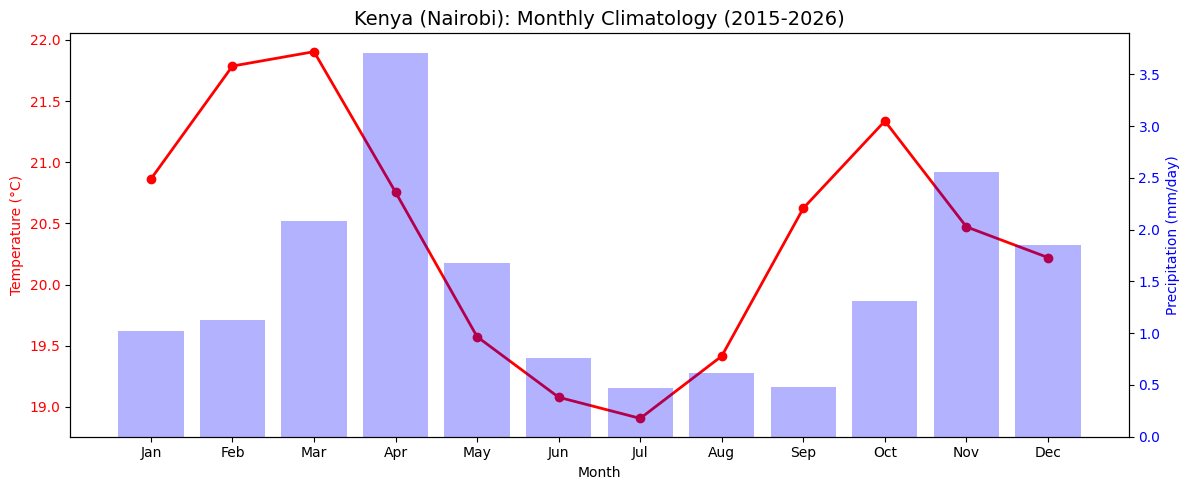

In [10]:
seasonal = df_clean.groupby('Month')[['T2M', 'PRECTOTCORR']].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(seasonal.index, seasonal['T2M'], 'r-o', linewidth=2)
ax1.set_xlabel('Month')
ax1.set_ylabel('Temperature (°C)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.bar(seasonal.index, seasonal['PRECTOTCORR'], alpha=0.3, color='blue')
ax2.set_ylabel('Precipitation (mm/day)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Kenya (Nairobi): Monthly Climatology (2015-2026)', fontsize=14)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

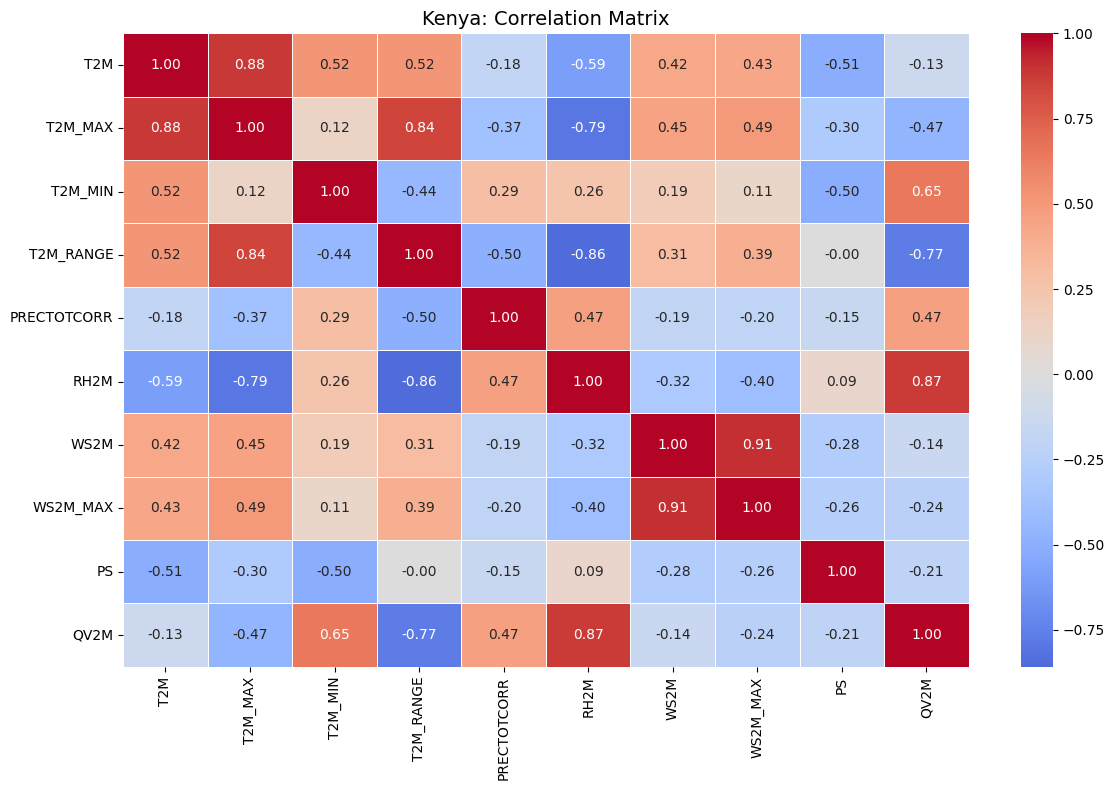

In [11]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Kenya: Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

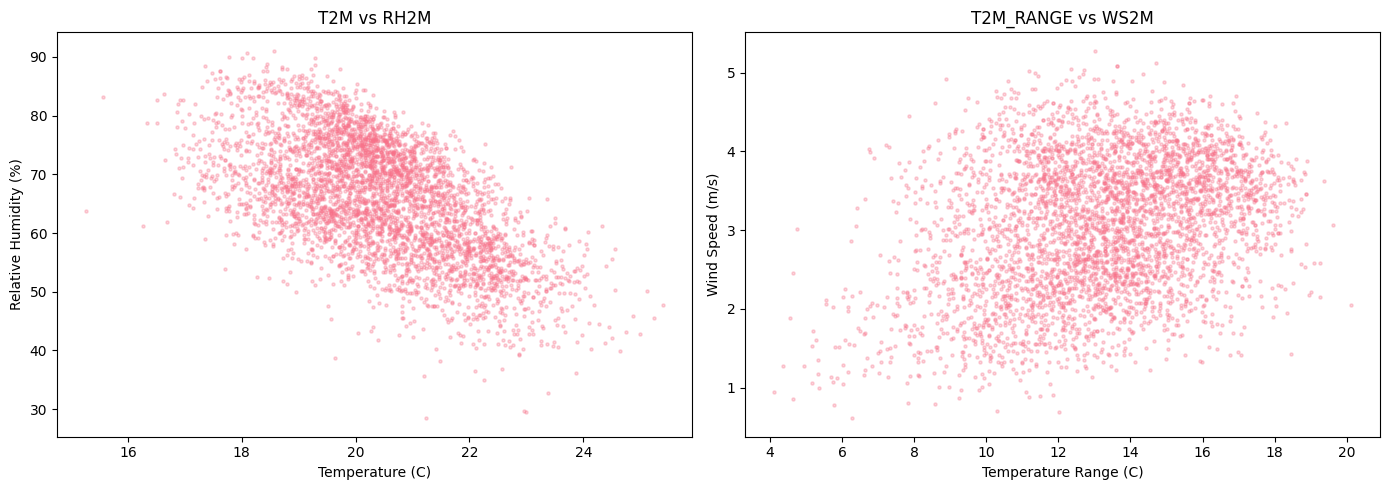

In [13]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_clean['T2M'], df_clean['RH2M'], alpha=0.3, s=5)
axes[0].set_xlabel('Temperature (C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('T2M vs RH2M')

axes[1].scatter(df_clean['T2M_RANGE'], df_clean['WS2M'], alpha=0.3, s=5)
axes[1].set_xlabel('Temperature Range (C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('T2M_RANGE vs WS2M')

plt.tight_layout()
plt.show()

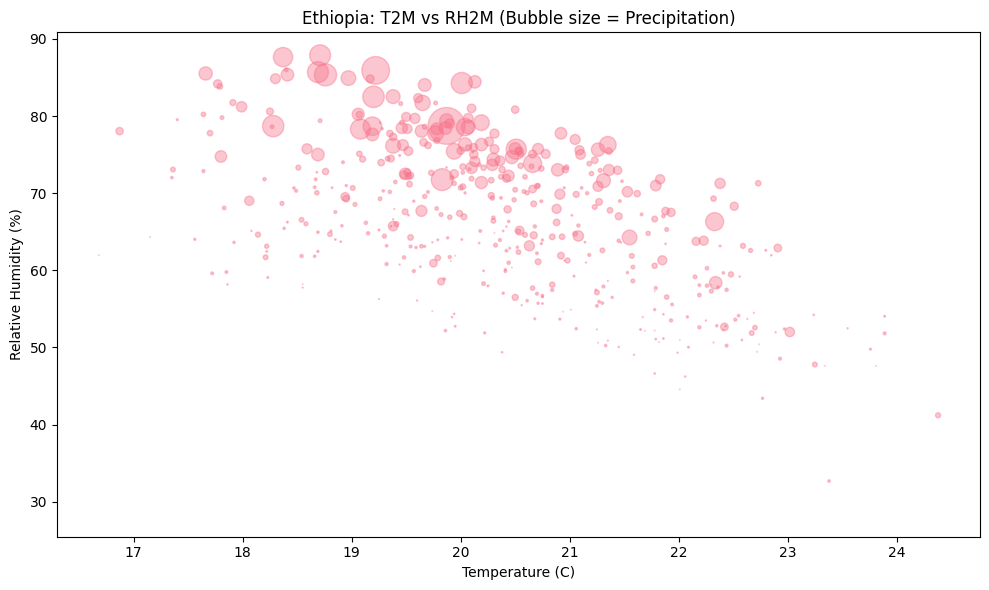

In [14]:
# Bubble chart: T2M vs RH2M, bubble size = precipitation
sample = df_clean.sample(min(500, len(df_clean)), random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*20, alpha=0.4)
plt.xlabel('Temperature (C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Ethiopia: T2M vs RH2M (Bubble size = Precipitation)')
plt.tight_layout()
plt.show()

In [15]:
# Kenya vs Ethiopia comparison
df_eth = pd.read_csv('../data/ethiopia_clean.csv')

print("=" * 50)
print("KENYA vs ETHIOPIA COMPARISON")
print("=" * 50)
print(f"Kenya Mean T2M:    {df_clean['T2M'].mean():.1f}°C  vs  Ethiopia: {df_eth['T2M'].mean():.1f}°C")
print(f"Kenya Mean Precip: {df_clean['PRECTOTCORR'].mean():.2f} mm  vs  Ethiopia: {df_eth['PRECTOTCORR'].mean():.2f} mm")
print(f"Kenya Max Precip:  {df_clean['PRECTOTCORR'].max():.1f} mm  vs  Ethiopia: {df_eth['PRECTOTCORR'].max():.1f} mm")

KENYA vs ETHIOPIA COMPARISON
Kenya Mean T2M:    20.4°C  vs  Ethiopia: 16.1°C
Kenya Mean Precip: 1.47 mm  vs  Ethiopia: 3.63 mm
Kenya Max Precip:  51.6 mm  vs  Ethiopia: 82.3 mm


## Kenya EDA Complete

Cleaned data saved to: data/kenya_clean.csv

**Key differences from Ethiopia:**
- Kenya is 4.3 degrees Celsius warmer due to lower elevation (1,795m vs 2,355m)
- Kenya has more rainy days but lighter precipitation (1.47 vs 3.63 mm/day)
- Kenya shows more stable temperatures (lower standard deviation)
- Both countries share the East African bimodal rainfall pattern

These elevation-driven climate differences between neighboring countries 
highlight the challenge of regional climate adaptation planning - solutions 
must be tailored to local conditions even within the same geographic region.